# Séance 5 : De NumPy à PyTorch, régression sur les manchots de Palmer

Dans ce notebook, on retrouve une tâche de régression que vous connaissez déjà bien (comme pour le prix des maisons), mais sur un nouveau jeu de données : les manchots de Palmer (Palmer Penguins).

Objectifs de la séance :
1. Reprendre en main un nouveau dataset (exploration rapide).
2. Ré-implémenter en NumPy la descente de gradient pour une régression linéaire (vous l'avez déjà fait à la main au tableau en TD4).
3. Découvrir PyTorch : tenseurs, calcul automatique du gradient (autograd), et optimiseurs, sur le même problème.

Ce notebook est prévu pour environ une heure de travail autonome.

**Avant de commencer : sélection du kernel.** Ce notebook a besoin de PyTorch, qui est préinstallé dans l'environnement virtuel situé dans `/opt/pytorch-env`. Dans VS Code, cliquez sur le sélecteur de kernel en haut à droite du notebook, puis choisissez l'interpréteur Python correspondant à `/opt/pytorch-env` (pas besoin de l'activer au préalable dans un terminal, VS Code le détecte directement). S'il n'apparaît pas dans la liste proposée, utilisez "Sélectionner un autre kernel" puis "Interpréteur Python", et naviguez jusqu'à `/opt/pytorch-env/bin/python`.

## Partie 0 : Découverte du dataset

Le jeu de données Palmer Penguins contient des mesures sur des manchots de trois espèces (Adelie, Chinstrap, Gentoo), vivant sur trois îles de l'archipel Palmer, en Antarctique.

Variables numériques :
- bill_length_mm (longueur du bec)
- bill_depth_mm (profondeur du bec)
- flipper_length_mm (longueur des nageoires)
- body_mass_g (masse corporelle)

Variables catégorielles :
- species (espèce)
- island (île)
- sex (sexe)

Aujourd'hui, on se concentre uniquement sur les variables numériques, pour prédire la masse corporelle (body_mass_g) à partir de la longueur du bec (bill_length_mm).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Chargement du dataset (via seaborn, qui l'intègre nativement)
import seaborn as sns
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [2]:
# Un petit coup d'oeil sur les données
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


Question 1. Combien y a-t-il de lignes avec des valeurs manquantes (NaN) dans le dataset ? Supprimez-les (on garde les choses simples aujourd'hui).

In [ ]:
# A vous de jouer
#print(penguins.isna().any(axis=1).sum())
penguins_clean = penguins.dropna()
penguins_clean.shape

0


(333, 7)

Question 2. Affichez un nuage de points (scatter) de body_mass_g en fonction de bill_length_mm. La relation vous semble-t-elle à peu près linéaire ?

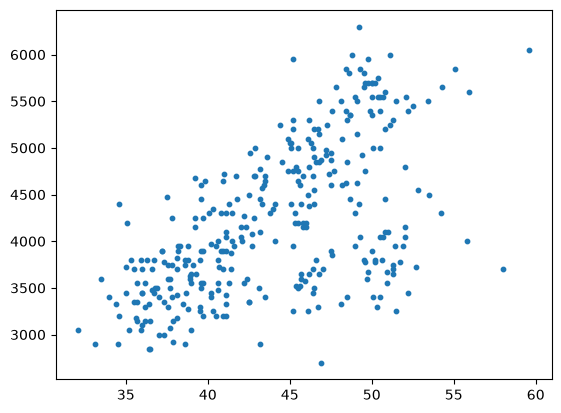

In [9]:
# A vous de jouer
plt.scatter(penguins_clean.bill_length_mm,penguins_clean.body_mass_g,s=10)

## Partie 1 : Retour aux fondamentaux, la descente de gradient en NumPy

Vous avez déjà, au TD4, dérivé à la main la règle de mise à jour des poids pour une régression linéaire à une variable avec la perte MSE. On reprend ici exactement les notations du cours et du TD4.

Le modèle est $f_w(x) = w_0 + w_1 x$.

On note $e_n(w) = f_w(x_n) - t_n$ l'erreur commise sur l'exemple $n$, où $t_n$ est la valeur cible observée.

La perte MSE s'écrit $E(w) = \dfrac{1}{2N}\sum_{n=1}^{N} e_n(w)^2$.

Les règles de mise à jour obtenues en TD4 sont :

$w_0 \leftarrow w_0 - \eta \dfrac{1}{N}\sum_{n=1}^N e_n(w)$

$w_1 \leftarrow w_1 - \eta \dfrac{1}{N}\sum_{n=1}^N e_n(w)\, x_n$

On va maintenant coder cet algorithme, pour x = bill_length_mm et t = body_mass_g.

Conseil : normalisez x et t avec le StandardScaler de scikit-learn (comme vu l'an dernier) avant de lancer la descente de gradient, sinon elle risque de diverger ou d'être très lente, vu l'échelle des valeurs (longueurs en mm, masses en grammes) ; comme vu en TD4, le pas eta doit être adapté à l'échelle des variables.

In [10]:
from sklearn.preprocessing import StandardScaler

# scikit-learn attend des tableaux de forme (N, 1), d'où les doubles crochets
x = penguins_clean[["bill_length_mm"]].values
t = penguins_clean[["body_mass_g"]].values

scaler_x = StandardScaler()
scaler_t = StandardScaler()

# On remet ensuite à plat (ravel) pour travailler avec des vecteurs de taille N
x_norm = scaler_x.fit_transform(x).ravel()
t_norm = scaler_t.fit_transform(t).ravel()

Question 3. Complétez la fonction gradient_descent ci-dessous, qui effectue n_iter itérations de descente de gradient pour la régression linéaire $f_w(x) = w_0 + w_1 x$, en suivant l'algorithme de référence du TD4.

In [11]:
def gradient_descent(x, t, eta=0.1, n_iter=100):
    w0, w1 = 0.0, 0.0
    N = len(x)
    history = []  # pour stocker l'évolution de la perte E(w)

    for i in range(n_iter):
        y = w0 + w1 * x
        e = y - t

        # A COMPLETER : calculez les gradients g0 et g1
        g0 = sum(e)/N
        g1 = sum(e * x)/N

        # A COMPLETER : mise à jour de w0 et w1
        w0 = w0 - eta *g0
        w1 = w1 - eta *g1

        E = np.mean(e ** 2) / 2
        history.append(E)

    return w0, w1, history

w0, w1, history = gradient_descent(x_norm, t_norm, eta=0.1, n_iter=100)
print(f"w0 = {w0:.4f}, w1 = {w1:.4f}")

w0 = -0.0000, w1 = 0.5894


Question 4. Tracez l'évolution de la perte E(w) au fil des itérations. La descente converge-t-elle ? Essayez avec différentes valeurs de eta : que se passe-t-il si eta est trop grand ? Trop petit ? (vous retrouverez les mêmes effets que ceux observés à la main en TD4).

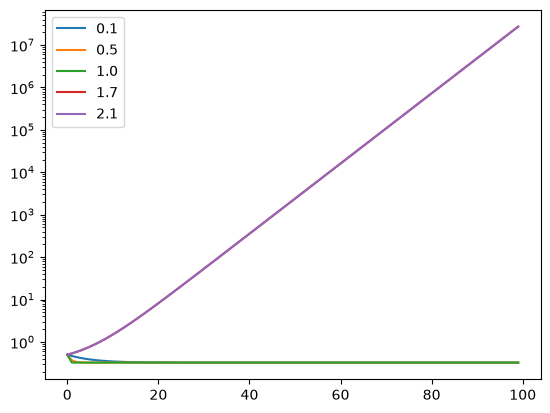

In [21]:
# A vous de jouer
w0, w1, history5 = gradient_descent(x_norm, t_norm, eta=0.5, n_iter=100)
w0, w1, history1 = gradient_descent(x_norm, t_norm, eta=1.0, n_iter=100)
w0, w1, history17 = gradient_descent(x_norm, t_norm, eta=1.7, n_iter=100)
w0, w1, history17 = gradient_descent(x_norm, t_norm, eta=2.1, n_iter=100)

plt.plot(history, label ="0.1")
plt.plot(history5, label = "0.5")
plt.plot(history1, label = "1.0" )
plt.plot(history17, label = "1.7")
plt.plot(history17, label = "2.1")
plt.yscale("log")
plt.legend()

Question 5. Affichez le nuage de points initial (en unités normalisées) avec la droite de régression trouvée par votre algorithme.

In [ ]:
# A vous de jouer


## Partie 2 : Le même problème, avec PyTorch

Vous venez de coder la descente de gradient à la main : à chaque itération, vous avez calculé vous-même les dérivées de E(w) par rapport à w0 et w1, avec des formules obtenues au tableau en TD4.

PyTorch permet d'automatiser deux choses :
- le calcul du gradient, qui serait vite impraticable à la main pour des modèles bien plus complexes (un réseau de neurones peut avoir des millions de paramètres) ; c'est ce qu'on appelle l'autograd ;
- la mise à jour des poids, via un optimiseur comme SGD.

L'idée centrale de l'autograd est la suivante : quand vous faites des calculs à partir de tenseurs pour lesquels vous avez demandé le suivi du gradient (requires_grad=True), PyTorch enregistre en coulisses, au fur et à mesure, toutes les opérations effectuées (additions, multiplications, etc.), sous la forme d'un graphe de calcul. Ensuite, un seul appel à la méthode .backward() suffit pour que PyTorch remonte ce graphe à l'envers et calcule automatiquement, par la règle de dérivation en chaîne, le gradient de la quantité finale (ici la perte) par rapport à chacun des tenseurs suivis. Concrètement, PyTorch refait pour vous, de façon systématique, exactement le travail de dérivation que vous avez fait à la main en TD4.

### 2.1 Un premier exemple très simple, pour comprendre autograd

Avant de revenir à notre problème de régression, prenons une fonction toute simple d'une seule variable, pour laquelle vous pouvez vérifier le résultat de tête : $f(x) = x^2$, dont la dérivée est $f'(x) = 2x$.

Question 6. Créez un tenseur x valant 3.0 avec requires_grad=True, calculez y = x ** 2, puis appelez y.backward(). Affichez x.grad et vérifiez qu'il correspond bien à la valeur attendue.

In [ ]:
import torch

# A vous de jouer
x = ...          # tenseur valant 3.0, avec requires_grad=True
y = ...           # y = x ** 2

y.backward()
print("Gradient calculé par autograd :", x.grad)
print("Valeur attendue (2x) :", 2 * 3.0)

Question 7. Que se passe-t-il si vous enlevez requires_grad=True sur x, et que vous essayez d'appeler .backward() sur y ? Testez-le dans la cellule ci-dessous (pour ne pas casser la suite, on utilise un autre nom de variable).

In [ ]:
# A vous de jouer (observation du message d'erreur, pas besoin de garder le code)


### 2.2 Des tableaux NumPy aux tenseurs PyTorch, pour notre problème de régression

On revient maintenant à la régression sur les manchots. Comme pour x ci-dessus, nos paramètres w0 et w1 vont être des tenseurs avec requires_grad=True, pour que PyTorch construise le graphe de calcul et puisse ensuite calculer leurs gradients automatiquement.

In [ ]:
x_t = torch.tensor(x_norm, dtype=torch.float32)
t_t = torch.tensor(t_norm, dtype=torch.float32)

w0_t = torch.zeros(1, requires_grad=True)
w1_t = torch.zeros(1, requires_grad=True)

print(w0_t, w1_t)

Question 8. Complétez le code ci-dessous pour calculer la prédiction, la perte E(w) (avec le même facteur 1/2 que dans le cours), puis utilisez .backward() pour calculer automatiquement les gradients, exactement comme vous venez de le faire sur $f(x)=x^2$. Affichez ensuite w0_t.grad et w1_t.grad : retrouvez-vous des valeurs cohérentes avec votre calcul NumPy de la Question 3, à la première itération ?

In [ ]:
y_t = ...     # w0_t + w1_t * x_t
loss = ...    # perte E(w) = 0.5 * torch.mean(...)

loss.backward()

print("Gradient de w0 :", w0_t.grad)
print("Gradient de w1 :", w1_t.grad)

### 2.3 Boucle d'entraînement complète avec un optimiseur

Vous savez maintenant obtenir automatiquement les gradients avec .backward(). Il reste à automatiser la mise à jour des poids, c'est-à-dire l'opération $w \leftarrow w - \eta \times \text{gradient}$ que vous avez écrite à la main dans la fonction gradient_descent.

C'est le rôle d'un optimiseur. Un optimiseur PyTorch (torch.optim.SGD par exemple) est un objet à qui l'on donne, une fois pour toutes, la liste des tenseurs à mettre à jour (ici [w0_t, w1_t]) et le pas d'apprentissage eta (paramètre lr). Ensuite, à chaque itération, il suffit d'appeler optimizer.step() pour qu'il applique la règle de mise à jour à partir des gradients déjà calculés par .backward(). SGD signifie Stochastic Gradient Descent, mais ici, comme on utilise tout le jeu de données à chaque pas, on fait en réalité de la descente de gradient classique (on reparlera de la variante stochastique plus tard dans le cours).

Question 9. Complétez la boucle d'entraînement ci-dessous. Attention à bien remettre les gradients à zéro à chaque itération avec optimizer.zero_grad(), sinon ils s'accumulent d'une itération à l'autre au lieu d'être recalculés.

In [ ]:
w0_t = torch.zeros(1, requires_grad=True)
w1_t = torch.zeros(1, requires_grad=True)

optimizer = torch.optim.SGD([w0_t, w1_t], lr=0.1)

history_torch = []

for i in range(100):
    optimizer.zero_grad()

    y_t = ...     # prédiction
    loss = ...    # perte E(w)

    loss.backward()
    optimizer.step()

    history_torch.append(loss.item())

print(f"w0 = {w0_t.item():.4f}, w1 = {w1_t.item():.4f}")

Question 10. Comparez vos résultats : les valeurs de w0 et w1 trouvées par PyTorch sont-elles proches de celles obtenues en NumPy à la Question 3 ? Tracez les deux courbes de perte (NumPy et PyTorch) sur le même graphique.

In [ ]:
# A vous de jouer


## Bilan

Vous avez retrouvé, sur un nouveau dataset, la mécanique de la descente de gradient que vous aviez dérivée à la main en TD4. Vous avez observé que PyTorch, grâce à l'autograd, calcule automatiquement les mêmes gradients que ceux que vous avez programmés en NumPy. Vous avez utilisé un optimiseur (SGD) pour automatiser la boucle de mise à jour des poids.

Prochaine séance : on reste sur le même dataset, mais on passera à une tâche de classification (prédire l'espèce ou le sexe du manchot), directement avec PyTorch.